In [18]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("dataset_co_mo2.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [ ]:
#gl_ct1 = ['STAT3','IL6RorST','TGFBR1or2','PDGFB'] # All values from the first column
#gl_ct1 =['PDGFRB', 'TGFB1', 'IL6']  # All values from the second column
#gl_ct2 = ['PDGFB', 'STAT3','TGFBR1','TGFBR2','IL6R', 'IL6ST'] # All values from the first column

gl_ct1 =['PDGFB','TGFB1', 'IL6R', 'IL6ST']  # All values from the second column
gl_ct2 = ['PDGFRB','TGFBR1','TGFBR2', 'IL6','STAT3'] # All values from the first column

In [ ]:
from scipy.sparse import issparse

ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_ct1]
adata_ct2_co = adata[ict2, gl_ct2]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_ct1, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_ct2, knn=5, random_state=42) 

print(adata_ct1_co)
print(adata_ct2_co)

if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 5
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0. 0. 0.]


In [ ]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_ct1]
adata_ct2_mo = adata[ict2, gl_ct2]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_ct1, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_ct2, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 5
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'


In [5]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documentos\vscode_working_dir\QuantumXCT\python\cc_grn_functions"

sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

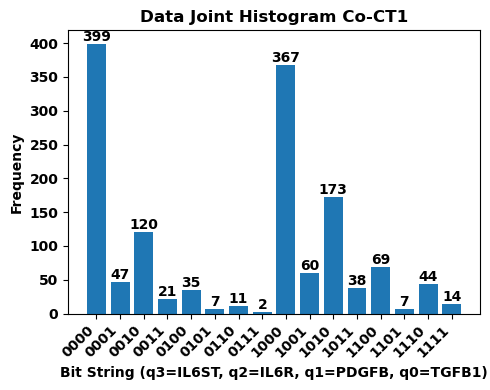

Joint Counts: Counter({'0000': 399, '1000': 367, '1010': 173, '0010': 120, '1100': 69, '1001': 60, '0001': 47, '1110': 44, '1011': 38, '0100': 35, '0011': 21, '1111': 14, '0110': 11, '1101': 7, '0101': 7, '0111': 2})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [ ]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_ct1, figsize = (5,4), 
                     #filename = 'joint_counts_co_ct1.svg', 
                     title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

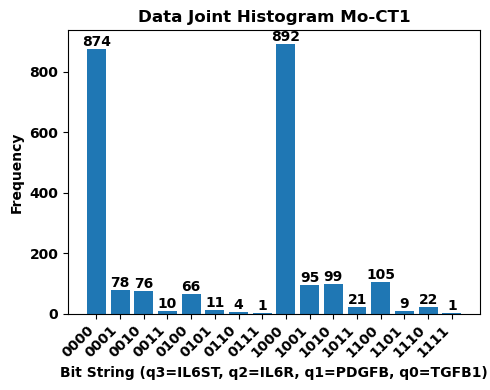

Joint Counts: Counter({'1000': 892, '0000': 874, '1100': 105, '1010': 99, '1001': 95, '0001': 78, '0010': 76, '0100': 66, '1110': 22, '1011': 21, '0101': 11, '0011': 10, '1101': 9, '0110': 4, '0111': 1, '1111': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [ ]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_ct1, figsize = (5,4),
                     #filename = 'joint_counts_mo_ct1.svg', 
                     title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

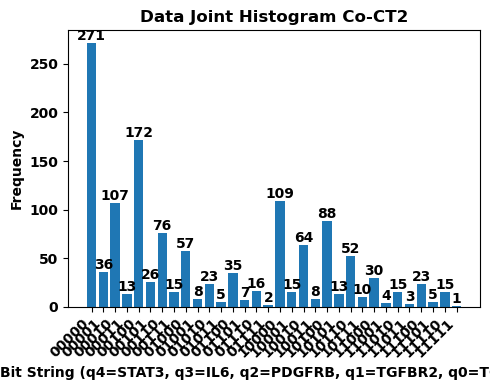

Joint Counts: Counter({'00000': 271, '00100': 172, '10000': 109, '00010': 107, '10100': 88, '00110': 76, '10010': 64, '01000': 57, '10110': 52, '00001': 36, '01100': 35, '11000': 30, '00101': 26, '11100': 23, '01010': 23, '01110': 16, '10001': 15, '11010': 15, '00111': 15, '11110': 15, '00011': 13, '10101': 13, '10111': 10, '10011': 8, '01001': 8, '01101': 7, '11101': 5, '01011': 5, '11001': 4, '11011': 3, '01111': 2, '11111': 1})
Bit Strings: ['00000', '00001', '00010', '00011', '00100', '00101', '00110', '00111', '01000', '01001', '01010', '01011', '01100', '01101', '01110', '01111', '10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000', '11001', '11010', '11011', '11100', '11101', '11110', '11111']


In [ ]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_ct2, figsize = (5,4), 
                     #filename = 'joint_counts_co_ct2.svg', 
                     title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

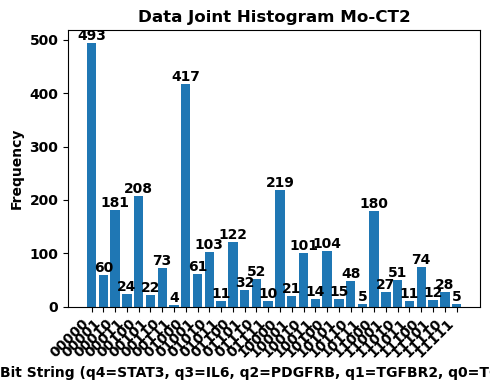

Joint Counts: Counter({'00000': 493, '01000': 417, '10000': 219, '00100': 208, '00010': 181, '11000': 180, '01100': 122, '10100': 104, '01010': 103, '10010': 101, '11100': 74, '00110': 73, '01001': 61, '00001': 60, '01110': 52, '11010': 51, '10110': 48, '01101': 32, '11110': 28, '11001': 27, '00011': 24, '00101': 22, '10001': 21, '10101': 15, '10011': 14, '11101': 12, '01011': 11, '11011': 11, '01111': 10, '11111': 5, '10111': 5, '00111': 4})
Bit Strings: ['00000', '00001', '00010', '00011', '00100', '00101', '00110', '00111', '01000', '01001', '01010', '01011', '01100', '01101', '01110', '01111', '10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000', '11001', '11010', '11011', '11100', '11101', '11110', '11111']


In [ ]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_ct2, figsize = (5,4), 
                     #filename = 'joint_counts_mo_ct2.svg', 
                     title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [10]:
from quantum_functions import vector_normalize_dictionary_values, create_initial_circuit2

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'1000': 892, '0000': 874, '1100': 105, '1010': 99, '1001': 95, '0001': 78, '0010': 76, '0100': 66, '1110': 22, '1011': 21, '0101': 11, '0011': 10, '1101': 9, '0110': 4, '0111': 1, '1111': 1})
State Set CT2 MO: Counter({'00000': 493, '01000': 417, '10000': 219, '00100': 208, '00010': 181, '11000': 180, '01100': 122, '10100': 104, '01010': 103, '10010': 101, '11100': 74, '00110': 73, '01001': 61, '00001': 60, '01110': 52, '11010': 51, '10110': 48, '01101': 32, '11110': 28, '11001': 27, '00011': 24, '00101': 22, '10001': 21, '10101': 15, '10011': 14, '11101': 12, '01011': 11, '11011': 11, '01111': 10, '11111': 5, '10111': 5, '00111': 4})
Interacted State Set CT1 CO: Counter({'0000': 399, '1000': 367, '1010': 173, '0010': 120, '1100': 69, '1001': 60, '0001': 47, '1110': 44, '1011': 38, '0100': 35, '0011': 21, '1111': 14, '0110': 11, '1101': 7, '0101': 7, '0111': 2})
Interacted State Set CT2 CO: Counter({'00000': 271, '00100': 17

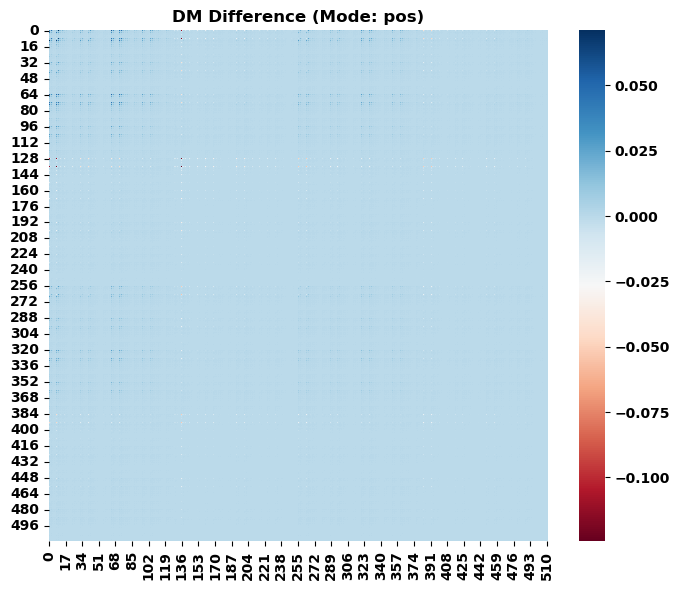


--- CNOT Analysis (pos) ---
Max Signal: 0.0711
Candidates Found: 18 / 72
------------------------------

{'max_element': 0.07107079130316898, 'min_element': -0.12447882698514154, 'abs_average': 0.0001846108823826683, 'relevant_avg': 0.00015568289194565409}


In [11]:
from quantum_functions import find_cnot_candidates_from_state_diff

thresh = 0.02
# --- State and Density Matrix Analysis ---
initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
    normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co,
    threshold = thresh, show_plot = True, search_mode="pos" , 
    verbose_print = True)

print(stats)


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---


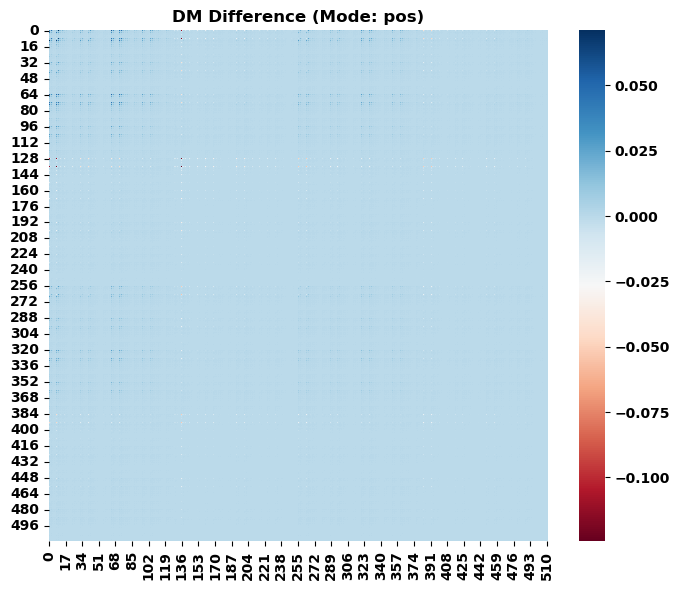


--- CNOT Analysis (pos) ---
Max Signal: 0.0711
Candidates Found: 18 / 72
------------------------------

Number of initial CNOT candidates: 18
Initial KL-divergence: 0.769095

  - Starting Efficiency-Optimized Search -

--- Iteration 1 | Current KL: 0.775113 ---
   - Single Insertion Phase: Added (3, 6) at index 0. New KL: 0.657687
  [Phase 1] Added Single: (3, 6) | New KL: 0.657687
  [Phase 2] Added Pair: ((1, 3), (6, 1)) | New KL: 0.602731

--- Iteration 2 | Current KL: 0.602731 ---
  - No improvements in any phase. Search Terminated.

--- Total Search Time: 193.30s ---

--- Pairwise Addition Result ---
Best sequence after addition: [(3, 6), (1, 3), (6, 1)]
KL sum after addition: 0.602731

Total search time: 194.06 seconds.

Multi-Epoch Search Optimal CNOT sequence found:
  q[3] -> q[6]
  q[1] -> q[3]
  q[6] -> q[1]
With minimum combined KL Divergence: 0.602731

--- Final Optimized Circuit ---
              »
         q_0: »
              »
         q_1: »
              »
         q

In [12]:
from quantum_functions import find_best_cnot_sequence_iterative_n_wise, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)

all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh,
    search_mode= "pos",
    nchoose=2,
    kl_tol = 0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0000': 2155, '1000': 1878, '1010': 642, '0010': 198, '0100': 9, '1001': 27, '0001': 29, '1011': 16, '1100': 23, '1110': 18, '0011': 2, '0110': 2, '0101': 1}
Counts for c_measure2: {'01100': 429, '00000': 1457, '01000': 1049, '00100': 709, '01010': 68, '00111': 2, '10000': 288, '00110': 108, '00001': 23, '10110': 38, '11000': 191, '10100': 154, '00010': 182, '10010': 75, '01110': 28, '10111': 2, '11100': 107, '00101': 10, '01001': 24, '10001': 3, '11101': 4, '00011': 2, '10101': 3, '11010': 16, '01101': 14, '10011': 2, '11001': 2, '11110': 9, '01111': 1}


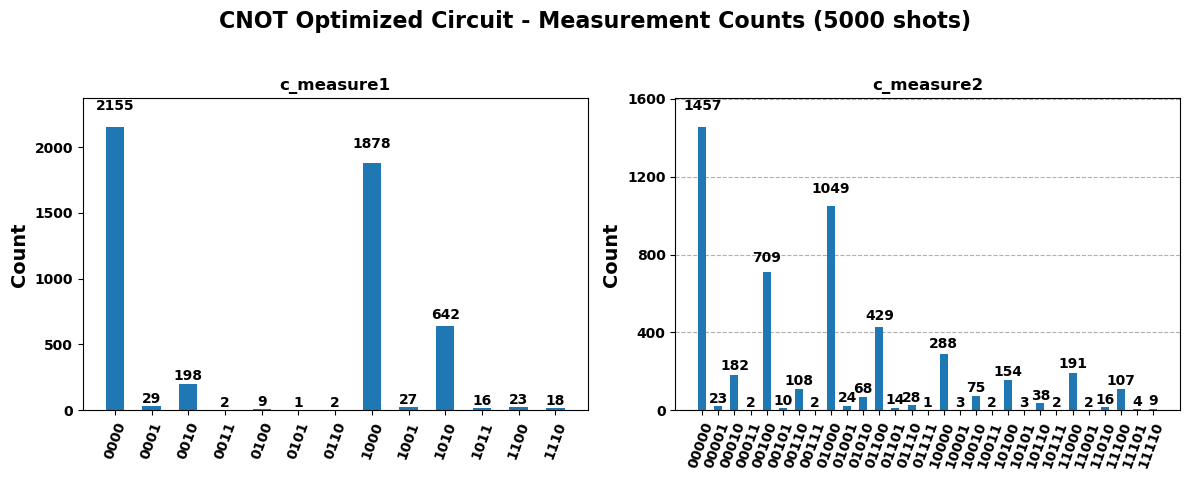

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


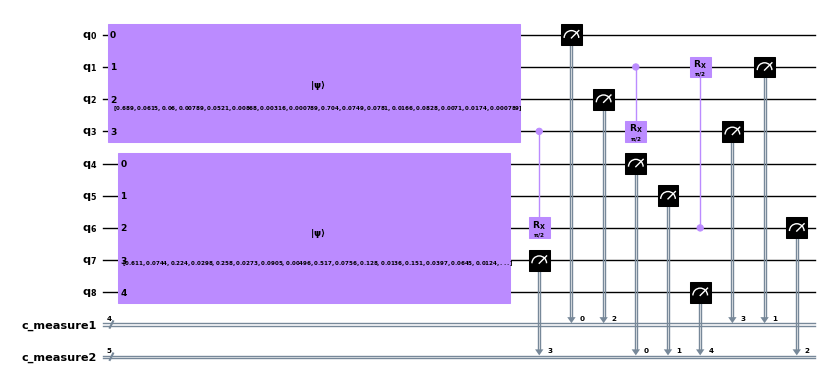

In [13]:
from quantum_functions import plot_measurement_histograms

measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

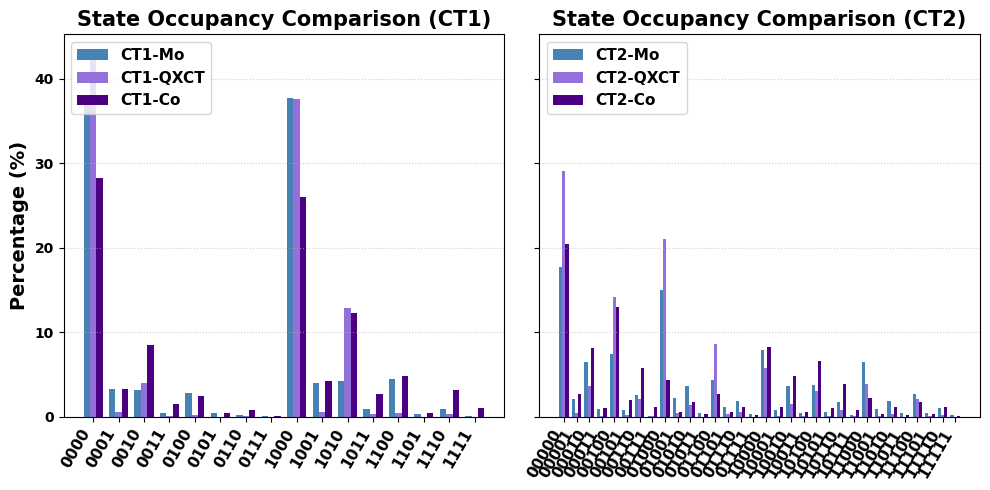

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (3 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.2561', '2.3988', '1.5157']
CRX Angle Optimization took: 16.24 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.2561', '2.3988', '1.5157']
  Minimum Combined KL Divergence with Optimized CRX: 0.597830


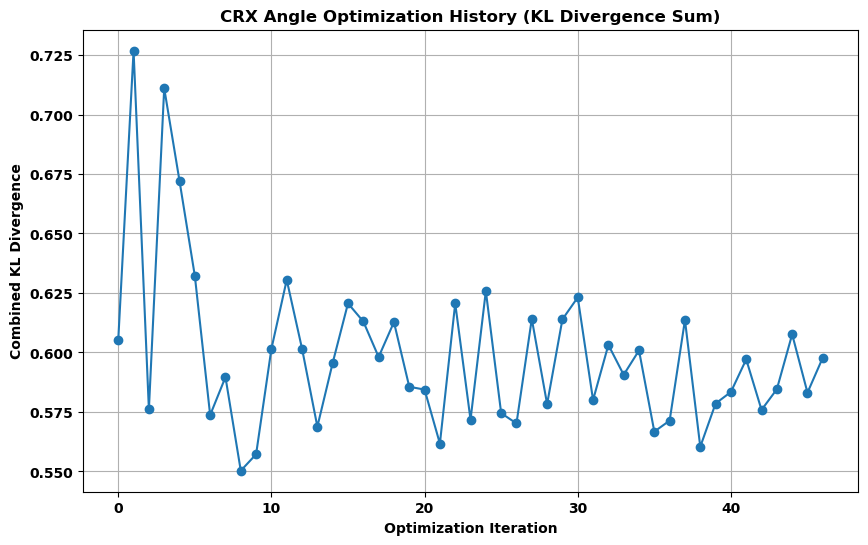


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
         q_7: »
              »
         q_8: »
              »
c_measure1: 4/»
              »
c_measure2: 5/»
              »
«                                                                             ┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐                                                              »
«         q_0: ───────────────────────────────────────────────────────────────┤0                                                                                                                                                                   ├──────────────────────────────────

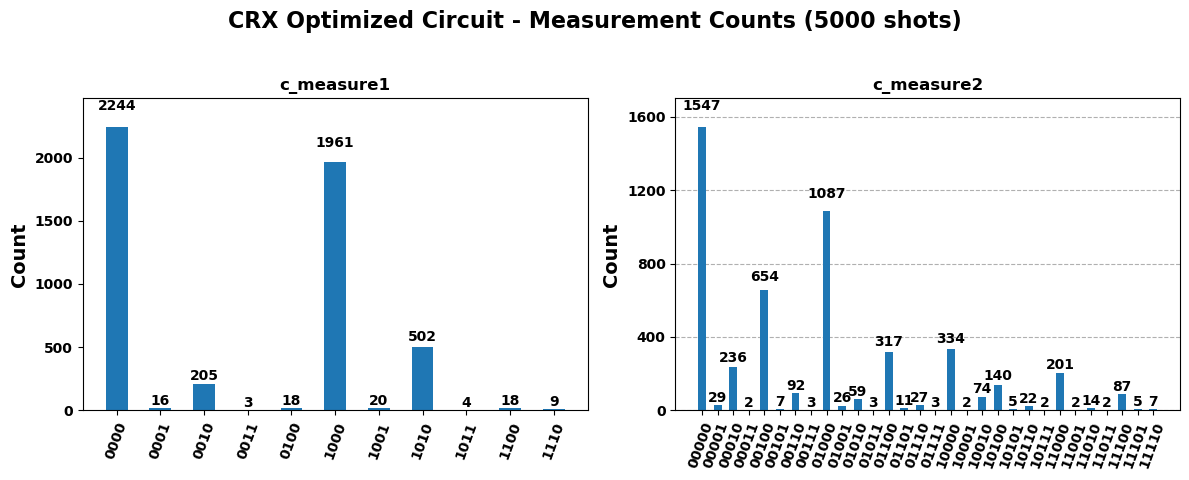

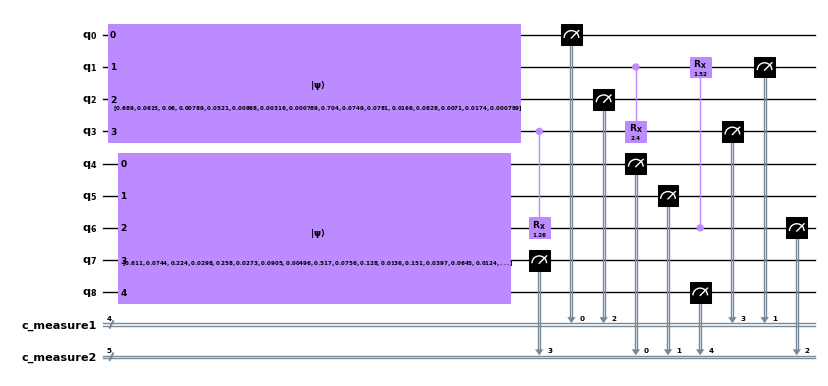

In [15]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.5)

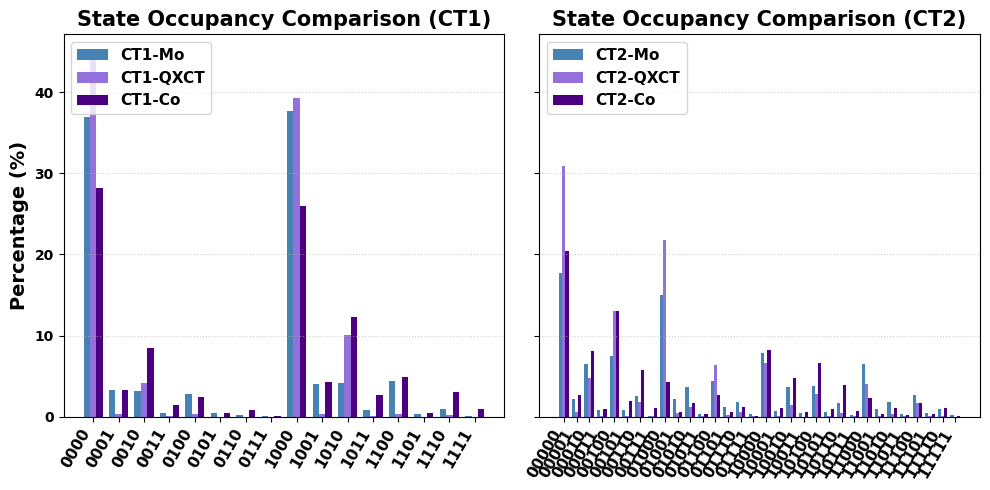

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---

--- Generating CNOT candidates from density matrix difference. ---


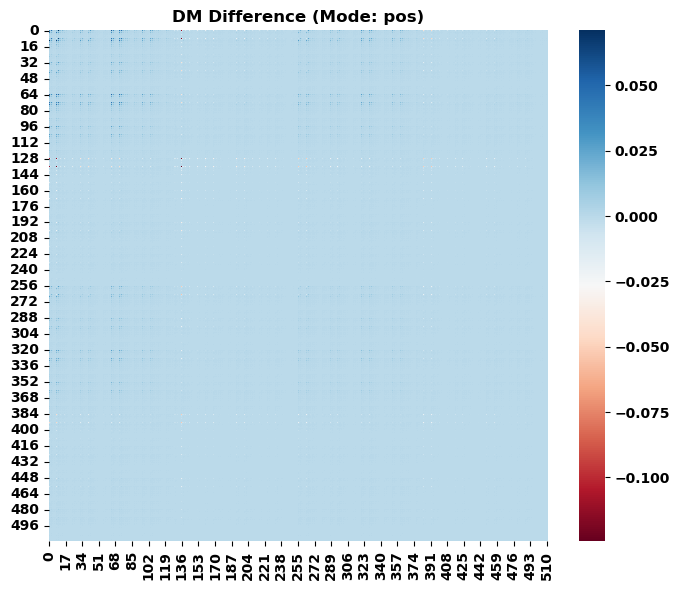


--- CNOT Analysis (pos) ---
Max Signal: 0.0711
Candidates Found: 18 / 72
------------------------------

Initial KL divergence (baseline): 0.779684

--- Starting Epoch 1/18 (Addition) with CNOT: (1, 5) (KL: 0.764571) ---
    --> Found a better KL on this path: 0.643187 at depth 2 with added CNOT (6, 1)
    --> Found a better KL on this path: 0.605645 at depth 3 with added CNOT (3, 6)
    --> Found a better KL on this path: 0.584921 at depth 4 with added CNOT (1, 6)
    --> Found a better KL on this path: 0.567948 at depth 5 with added CNOT (5, 1)
  Epoch 1 best KL Sum: 0.567948
  --> Epoch 1 found a new overall best KL Sum: 0.567948

--- Starting Greedy CNOT Removal Search on Best Found Sequence ---
  Starting removal search with 5 CNOTs (KL Sum: 0.567948)
  No CNOT removal improved the score. Stopping removal search.

--- Starting Epoch 2/18 (Addition) with CNOT: (1, 3) (KL: 0.780704) ---
  Skipping epoch: Single CNOT KL (0.780704) does not improve over baseline (0.779684).

--- Star

In [17]:
from quantum_functions import find_best_cnot_sequence_multi_epoch

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 50
min_greedy_depth = 20

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=thresh,
    search_mode="pos",
    kl_tol = 0.05
)


print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'101011': 165, '000000': 811, '000011': 103, '100000': 441, '001000': 76, '101010': 421, '100010': 1089, '101001': 46, '100110': 32, '000001': 84, '000010': 1050, '011110': 1, '001010': 206, '001001': 29, '001011': 59, '101000': 133, '000110': 22, '100001': 37, '110010': 15, '001111': 4, '100011': 75, '111010': 9, '101100': 5, '001110': 7, '010010': 5, '000100': 10, '001101': 1, '101110': 13, '100100': 13, '011010': 1, '000111': 3, '111011': 8, '110110': 1, '100111': 4, '111000': 3, '000101': 2, '110000': 4, '101111': 6, '010011': 1, '011000': 1, '111110': 1, '100101': 2, '111001': 1}
Counts for c_measure2: {'001': 326, '101': 163, '000': 1480, '011': 410, '010': 936, '110': 541, '111': 241, '100': 903}


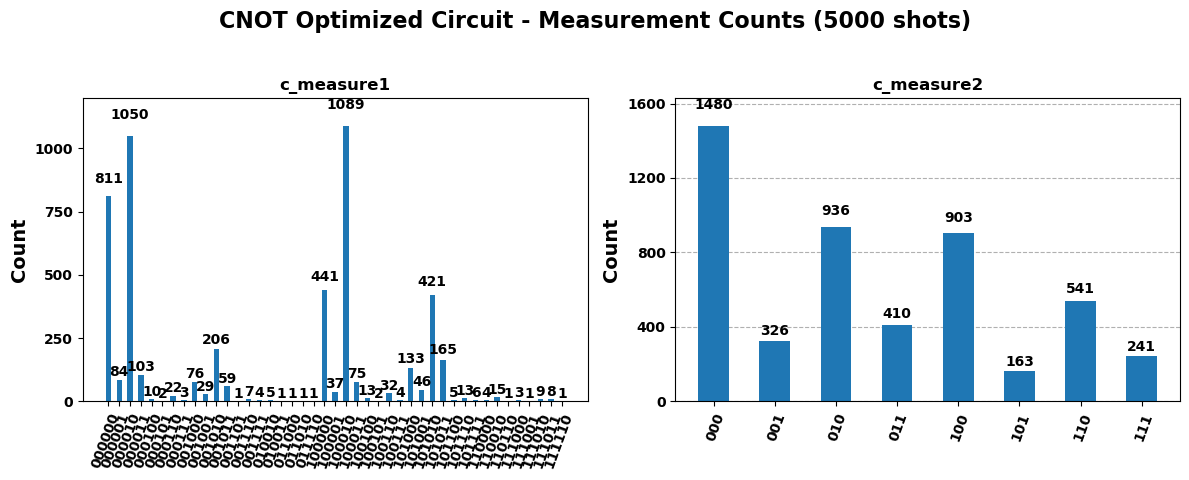

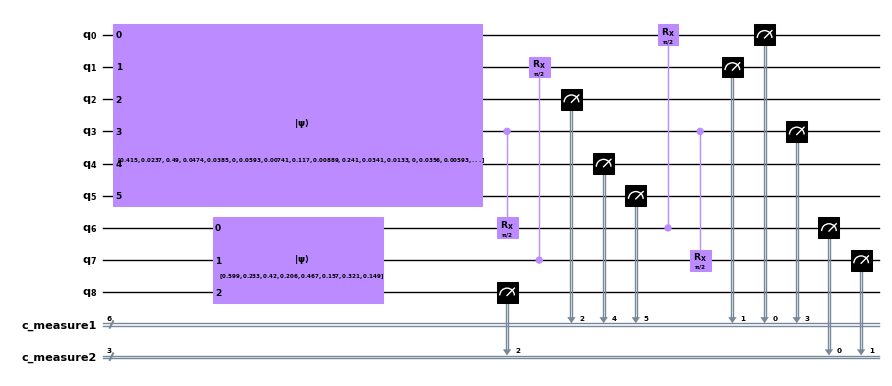

In [18]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

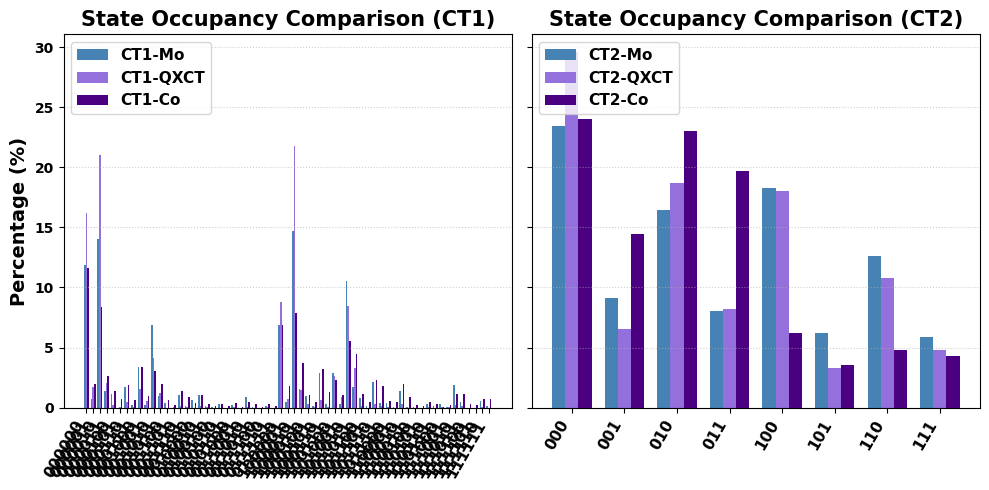

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.3359', '1.4950', '1.5466', '1.5475']
CRX Angle Optimization took: 27.49 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.3359', '1.4950', '1.5466', '1.5475']
  Minimum Combined KL Divergence with Optimized CRX: 0.633543


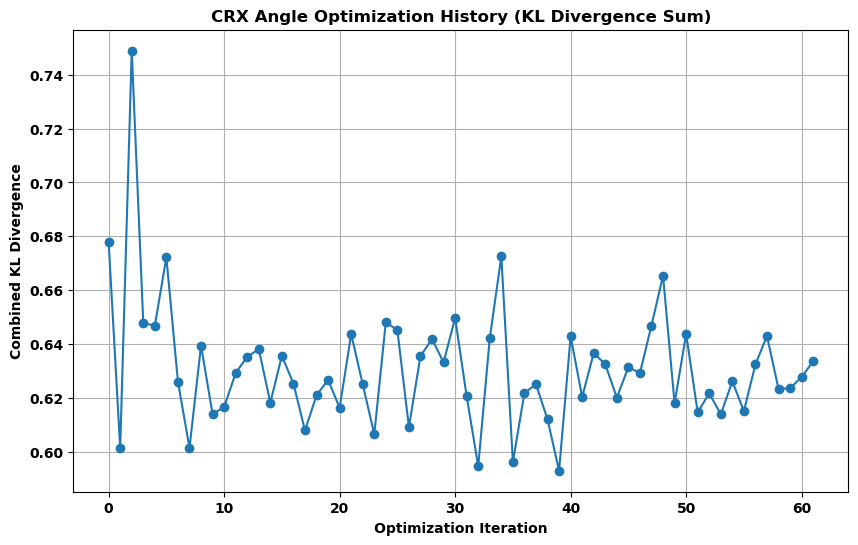


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
         q_7: »
              »
         q_8: »
              »
c_measure1: 6/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                        

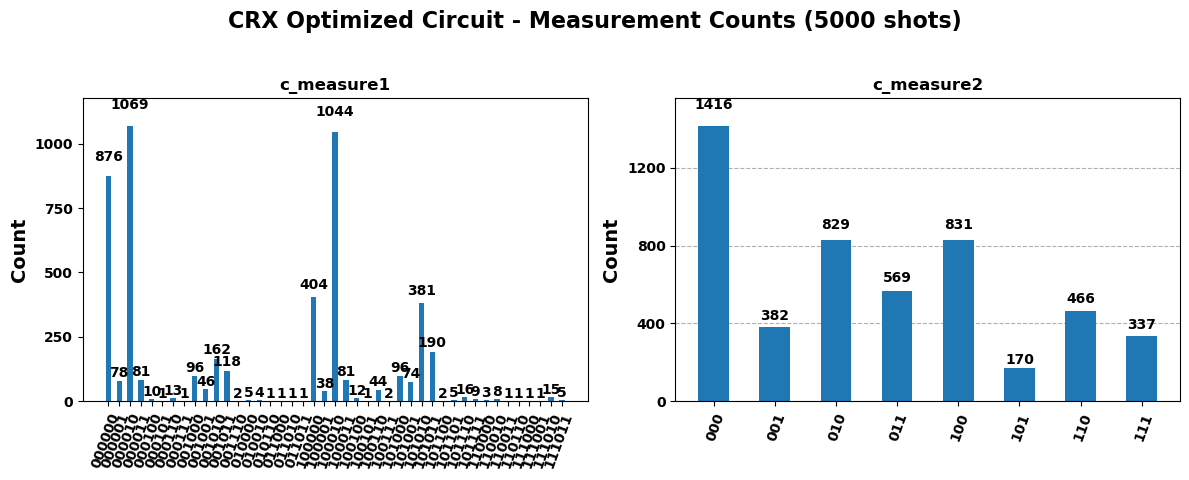

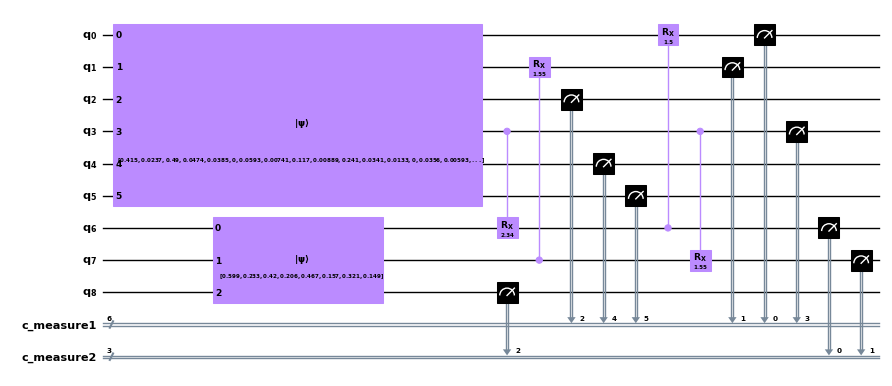

In [20]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.5)

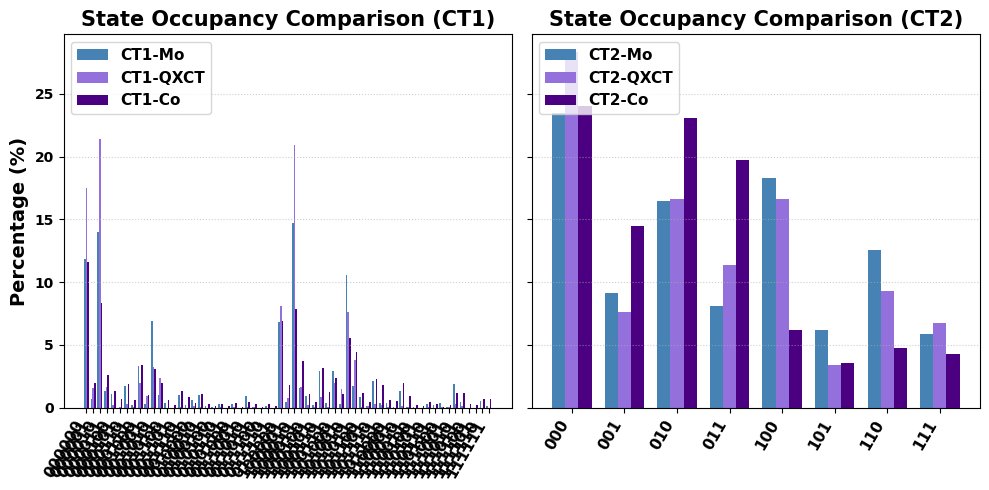

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---


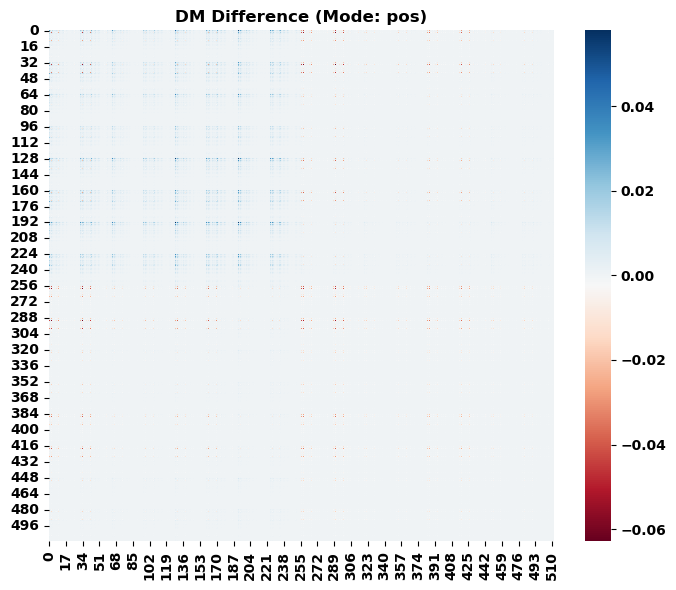


--- CNOT Analysis (pos) ---
Max Signal: 0.0580
Candidates Found: 40 / 72
------------------------------

Initial KL Divergence (no CNOTs): 0.922691

--- Building KL Divergence Matrix (40x40) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 1560
--- KL Divergence Matrix Built ---


In [22]:
from quantum_functions import build_kl_divergence_matrix_interaction

thresh = 0.01
np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)

kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_interaction(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh, 
    search_mode= "pos",
    include_single_cnot_kl=True
)

In [23]:
from quantum_functions import kl_to_qubo_matrix

# Creating Q matrix 
kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)

In [24]:
from qiskit_optimization import QuadraticProgram
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Assume kl_div_mat_qubo is your 42x42 NumPy array

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# Set the objective function to minimize the cost defined by the QUBO matrix
# The matrix must be passed as the 'quadratic' term.
qp.minimize(quadratic=kl_div_mat_qubo)

# --- 2. Convert the QUBO to an Ising Hamiltonian ---
# The Ising Converter performs the necessary transformation (x = (1 - Z)/2)
hamiltonian, offset = qp.to_ising()
print(offset)
print(hamiltonian)

3.9730969889795045
SparsePauliOp(['...'],
              coeffs=[-2.51979560e-01+0.j,  3.74467392e-03+0.j,  2.45223040e-02+0.j,
  1.22350106e-02+0.j, -2.26543630e-01+0.j,  5.97062242e-03+0.j,
 -1.96583513e-01+0.j,  3.71004733e-04+0.j, -6.14578412e-02+0.j,
  4.06843293e-04+0.j, -1.97706826e-01+0.j, -9.88502134e-03+0.j,
 -9.78032439e-02+0.j,  4.30878683e-03+0.j,  8.83944243e-03+0.j,
  7.23841432e-03+0.j, -2.86799998e-01+0.j,  4.04695886e-03+0.j,
 -9.44925845e-02+0.j,  1.36979041e-02+0.j, -3.99654100e-01+0.j,
  4.26020973e-03+0.j, -2.17435747e-01+0.j,  7.80171703e-03+0.j,
  5.52270846e-03+0.j,  8.11754967e-03+0.j, -1.24549034e-01+0.j,
  2.07431204e-02+0.j, -4.61441543e-01+0.j,  6.03524045e-03+0.j,
 -2.81756059e-01+0.j,  1.01544273e-02+0.j, -2.92898159e-01+0.j,
  5.08486345e-03+0.j, -2.46077941e-01+0.j,  7.30154766e-03+0.j,
  4.83787137e-02+0.j,  3.40032613e-03+0.j,  1.28398517e-01+0.j,
  4.09588895e-03+0.j, -1.43644126e-01+0.j,  1.40676724e-02+0.j,
 -2.87812029e-01+0.j,  7.93467421e-03+0.j

In [25]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
import numpy as np

# --- 1. Configuration (Example values) ---
num_qubits = kl_div_mat_qubo.shape[0]
reps = 1
entanglement = 'circular'  # linear sca circular pairwise reverse_linear full

# --- 2. Ansatz Creation ---
ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)

basis_gates = ['u', 'cx'] 
# 2. Transpile the circuit to decompose it into the basis gates.
expanded_ansatz = transpile(
    ansatz, 
    basis_gates = basis_gates, 
    optimization_level = 0  # Set to 0 to minimize changes beyond decomposition
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
backend = AerSimulator()
#backend = service.least_busy(operational=True, simulator=False)
#expanded_ansatz.draw()

C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_9872\2260493373.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)


In [26]:
from quantum_functions import vqe_solver
result, optimized_params, cost_values = vqe_solver(
    expanded_ansatz,
    hamiltonian,
    backend,
    optimizer_method="COBYLA", # COBYLA | L-BFGS-B 
    niter= 200
)

# Plot the cost function values
plt.figure(figsize=(5, 4))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
#plt.savefig('vqe_opt_curve_qmat.svg', bbox_inches='tight')
plt.show()    

Starting optimization with method: COBYLA


Simulation failed and returned the following error message:
ERROR:  [Experiment 0] Insufficient memory to run circuit EfficientSU2-468145 using the statevector simulator. Required memory: 16777216M, max memory: 32456M


QiskitError: 'ERROR:  [Experiment 0] Insufficient memory to run circuit EfficientSU2-468145 using the statevector simulator. Required memory: 16777216M, max memory: 32456M ,  ERROR: Insufficient memory to run circuit EfficientSU2-468145 using the statevector simulator. Required memory: 16777216M, max memory: 32456M'